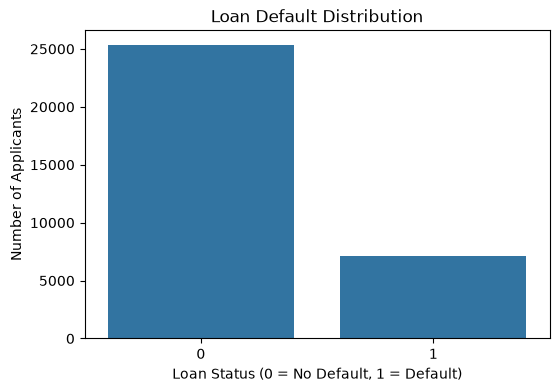

In [ ]:
## EDA — Graph 1: Default Distribution
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/credit_risk_cleaned.csv")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="loan_status")

plt.title("Loan Default Distribution")
plt.xlabel("Loan Status (0 = No Default, 1 = Default)")
plt.ylabel("Number of Applicants")

plt.show()

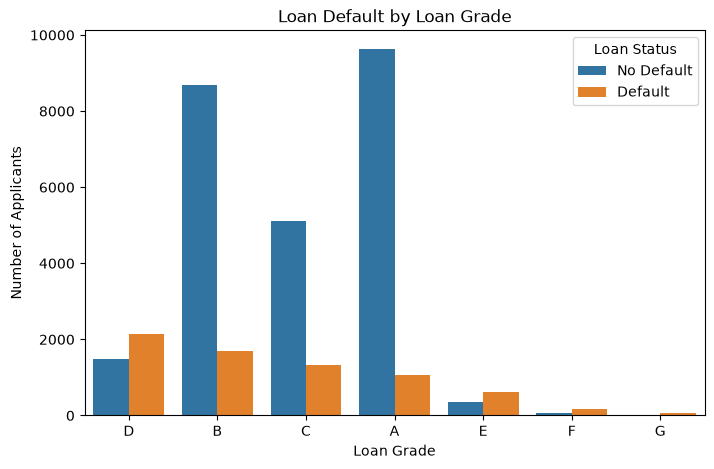

In [ ]:
## Graph 2 — Default by Loan Grade
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="loan_grade",
    hue="loan_status"
)

plt.title("Loan Default by Loan Grade")
plt.xlabel("Loan Grade")
plt.ylabel("Number of Applicants")
plt.legend(
    title="Loan Status",
    labels=["No Default", "Default"]
)

plt.show()

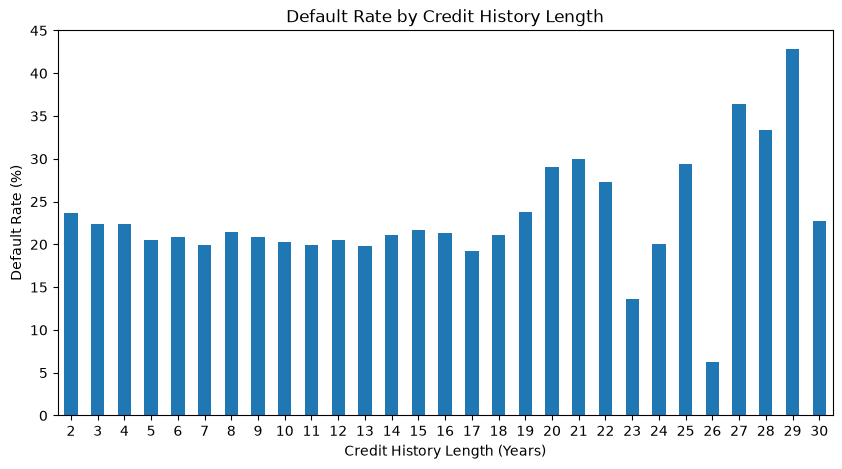

In [4]:
## Graph 3 — Default by Credit History Length
plt.figure(figsize=(10, 5))

default_rate = df.groupby("cb_person_cred_hist_length")["loan_status"].mean() * 100

default_rate.plot(kind="bar")

plt.title("Default Rate by Credit History Length")
plt.xlabel("Credit History Length (Years)")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

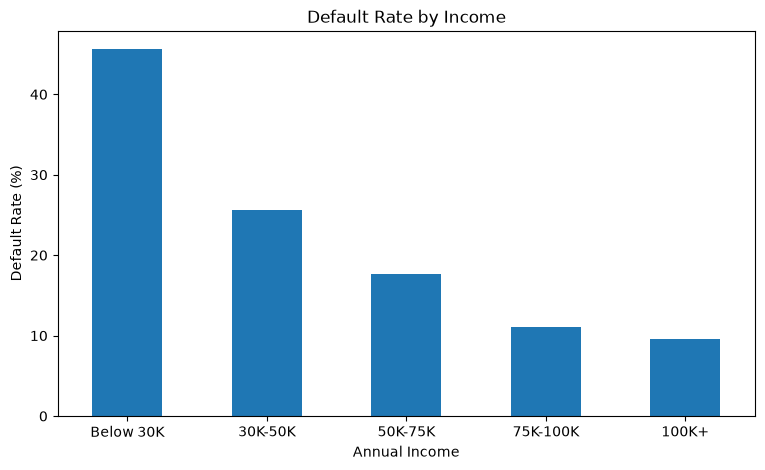

In [5]:
## Graph 4 — Default Rate by Income 
df["income_group"] = pd.cut(
    df["person_income"],
    bins=[0, 30000, 50000, 75000, 100000, float("inf")],
    labels=[
        "Below 30K",
        "30K-50K",
        "50K-75K",
        "75K-100K",
        "100K+"
    ]
)

default_rate = df.groupby(
    "income_group",
    observed=False
)["loan_status"].mean() * 100

plt.figure(figsize=(9, 5))

default_rate.plot(kind="bar")

plt.title("Default Rate by Income")
plt.xlabel("Annual Income")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

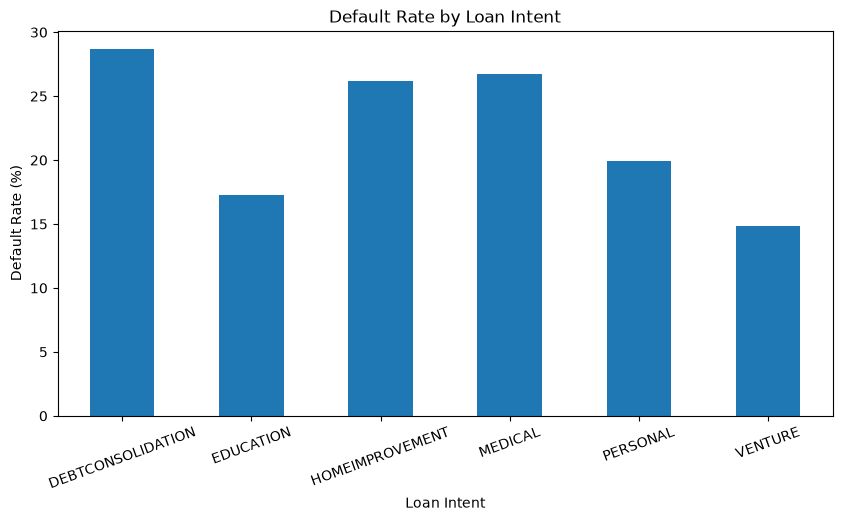

In [6]:
## Graph 5 — Default Rate by Loan Intent
default_rate = df.groupby("loan_intent")["loan_status"].mean() * 100

plt.figure(figsize=(10, 5))

default_rate.plot(kind="bar")

plt.title("Default Rate by Loan Intent")
plt.xlabel("Loan Intent")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=20)

plt.show()

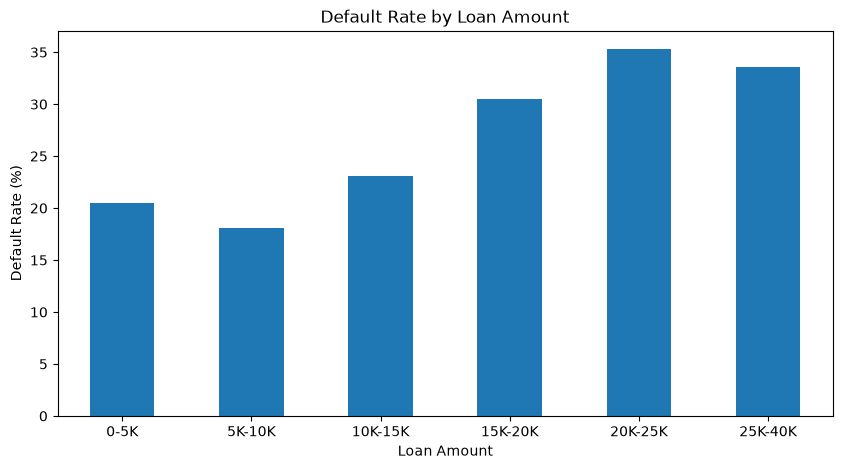

In [7]:
## Graph 6 — Default Rate by Loan Amount
df["loan_amount_group"] = pd.cut(
    df["loan_amnt"],
    bins=[0, 5000, 10000, 15000, 20000, 25000, 40000],
    labels=[
        "0-5K",
        "5K-10K",
        "10K-15K",
        "15K-20K",
        "20K-25K",
        "25K-40K"
    ]
)

default_rate = df.groupby(
    "loan_amount_group",
    observed=False
)["loan_status"].mean() * 100

plt.figure(figsize=(10, 5))

default_rate.plot(kind="bar")

plt.title("Default Rate by Loan Amount")
plt.xlabel("Loan Amount")
plt.ylabel("Default Rate (%)")
plt.xticks(rotation=0)

plt.show()

In [8]:
## EDA Insights
print("=== EDA INSIGHTS ===")

print("\n1. Overall Default Rate:")
print(df["loan_status"].mean() * 100)

print("\n2. Default Rate by Loan Grade:")
print(
    df.groupby("loan_grade")["loan_status"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\n3. Default Rate by Credit History Length:")
print(
    df.groupby("cb_person_cred_hist_length")["loan_status"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print("\n4. Default Rate by Loan Intent:")
print(
    df.groupby("loan_intent")["loan_status"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

=== EDA INSIGHTS ===

1. Overall Default Rate:
21.872203881398292

2. Default Rate by Loan Grade:
loan_grade
G    98.437500
F    70.539419
E    64.485981
D    59.060773
C    20.758235
B    16.323190
A     9.959824
Name: loan_status, dtype: float64

3. Default Rate by Credit History Length:
cb_person_cred_hist_length
29    42.857143
27    36.363636
28    33.333333
21    30.000000
25    29.411765
20    29.032258
22    27.272727
19    23.809524
2     23.700203
30    22.727273
4     22.414966
3     22.378452
15    21.739130
8     21.394612
16    21.380846
14    21.138211
18    21.052632
6     20.822066
9     20.815678
5     20.533333
12    20.496894
10    20.314193
24    20.000000
7     19.915701
11    19.913420
13    19.864560
17    19.211823
23    13.636364
26     6.250000
Name: loan_status, dtype: float64

4. Default Rate by Loan Intent:
loan_intent
DEBTCONSOLIDATION    28.676045
MEDICAL              26.762661
HOMEIMPROVEMENT      26.154702
PERSONAL             19.901765
EDUCATION      

## EDA Insights

- Overall loan default rate is approximately **21.87%**.

- Loan Grade has a strong relationship with loan default. **Grade G** has the highest default rate at approximately **98.44%**, while **Grade A** has the lowest default rate at approximately **9.96%**.

- Default rates vary across different credit history lengths. Some longer credit history groups show higher default rates, but these groups have fewer applicants, so they should be interpreted carefully.

- **Debt Consolidation** has the highest default rate among loan intents at approximately **28.68%**, followed by **Medical** at **26.76%** and **Home Improvement** at **26.15%**.

- **Venture** loans have the lowest default rate at approximately **14.86%**, followed by **Education** loans at **17.26%**.

- Overall, loan grade and loan intent show noticeable differences in default rates and can be useful features for the credit risk prediction model.